# Exploratory Data Analysis (EDA)

In [1]:
from pathlib import Path
import math
import sys
from typing import Optional
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.data_processing.load_data import load_heart_data
from src.data_processing.preprocess import CONTINUOUS_FEATURES

In [2]:
def find_project_root(start: Optional[Path] = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "heart.csv").exists():
            return candidate
    raise FileNotFoundError("Project root not found (expected data/heart.csv)")
ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Read dataset & Overview of the data

In [8]:
data = load_heart_data()
display(data.head())


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [9]:
print("Shape:", data.shape)

Shape: (303, 14)


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [11]:
display(data.describe(include="all").T)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [12]:
display(data.isna().sum().to_frame("missing_values"))

,missing_values
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## Features Classification: Continuous & Categorical

In [13]:
# Separate features by type
categorical_features = [column for column in data.columns if column not in CONTINUOUS_FEATURES]
categorical_no_target = [c for c in categorical_features if c != "target"]
print("Continuous features:", CONTINUOUS_FEATURES)
print("Categorical features:", categorical_features)

Continuous features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


In [14]:
display(data[CONTINUOUS_FEATURES].describe().T)
display(data[categorical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


,count,mean,std,min,25%,50%,75%,max
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
slope,303.0,1.399340,0.616226,0.0,1.0,1.0,2.0,2.0
ca,303.0,0.729373,1.022606,0.0,0.0,0.0,1.0,4.0
thal,303.0,2.313531,0.612277,0.0,2.0,2.0,3.0,3.0
target,303.0,0.544554,0.498835,0.0,0.0,1.0,1.0,1.0


## Visualizations

### Correlation Heatmap for Continuous Features

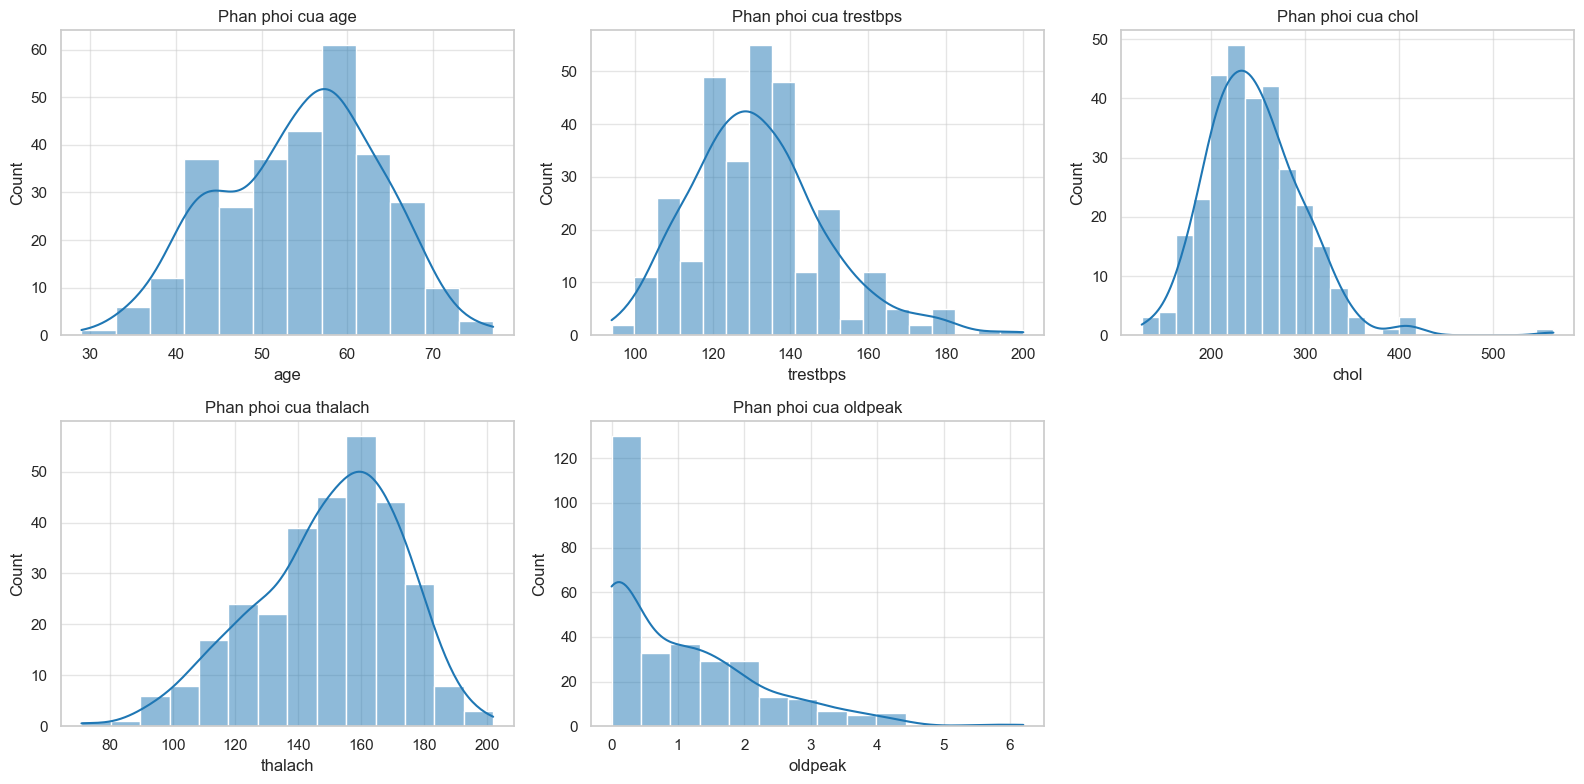

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for ax, column in zip(axes, CONTINUOUS_FEATURES):
    sns.histplot(data[column], kde=True, ax=ax, color="#1f77b4")
    ax.set_title(f"Phan phoi cua {column}")
for ax in axes[len(CONTINUOUS_FEATURES):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Count Plots for Categorical Features (excluding target)

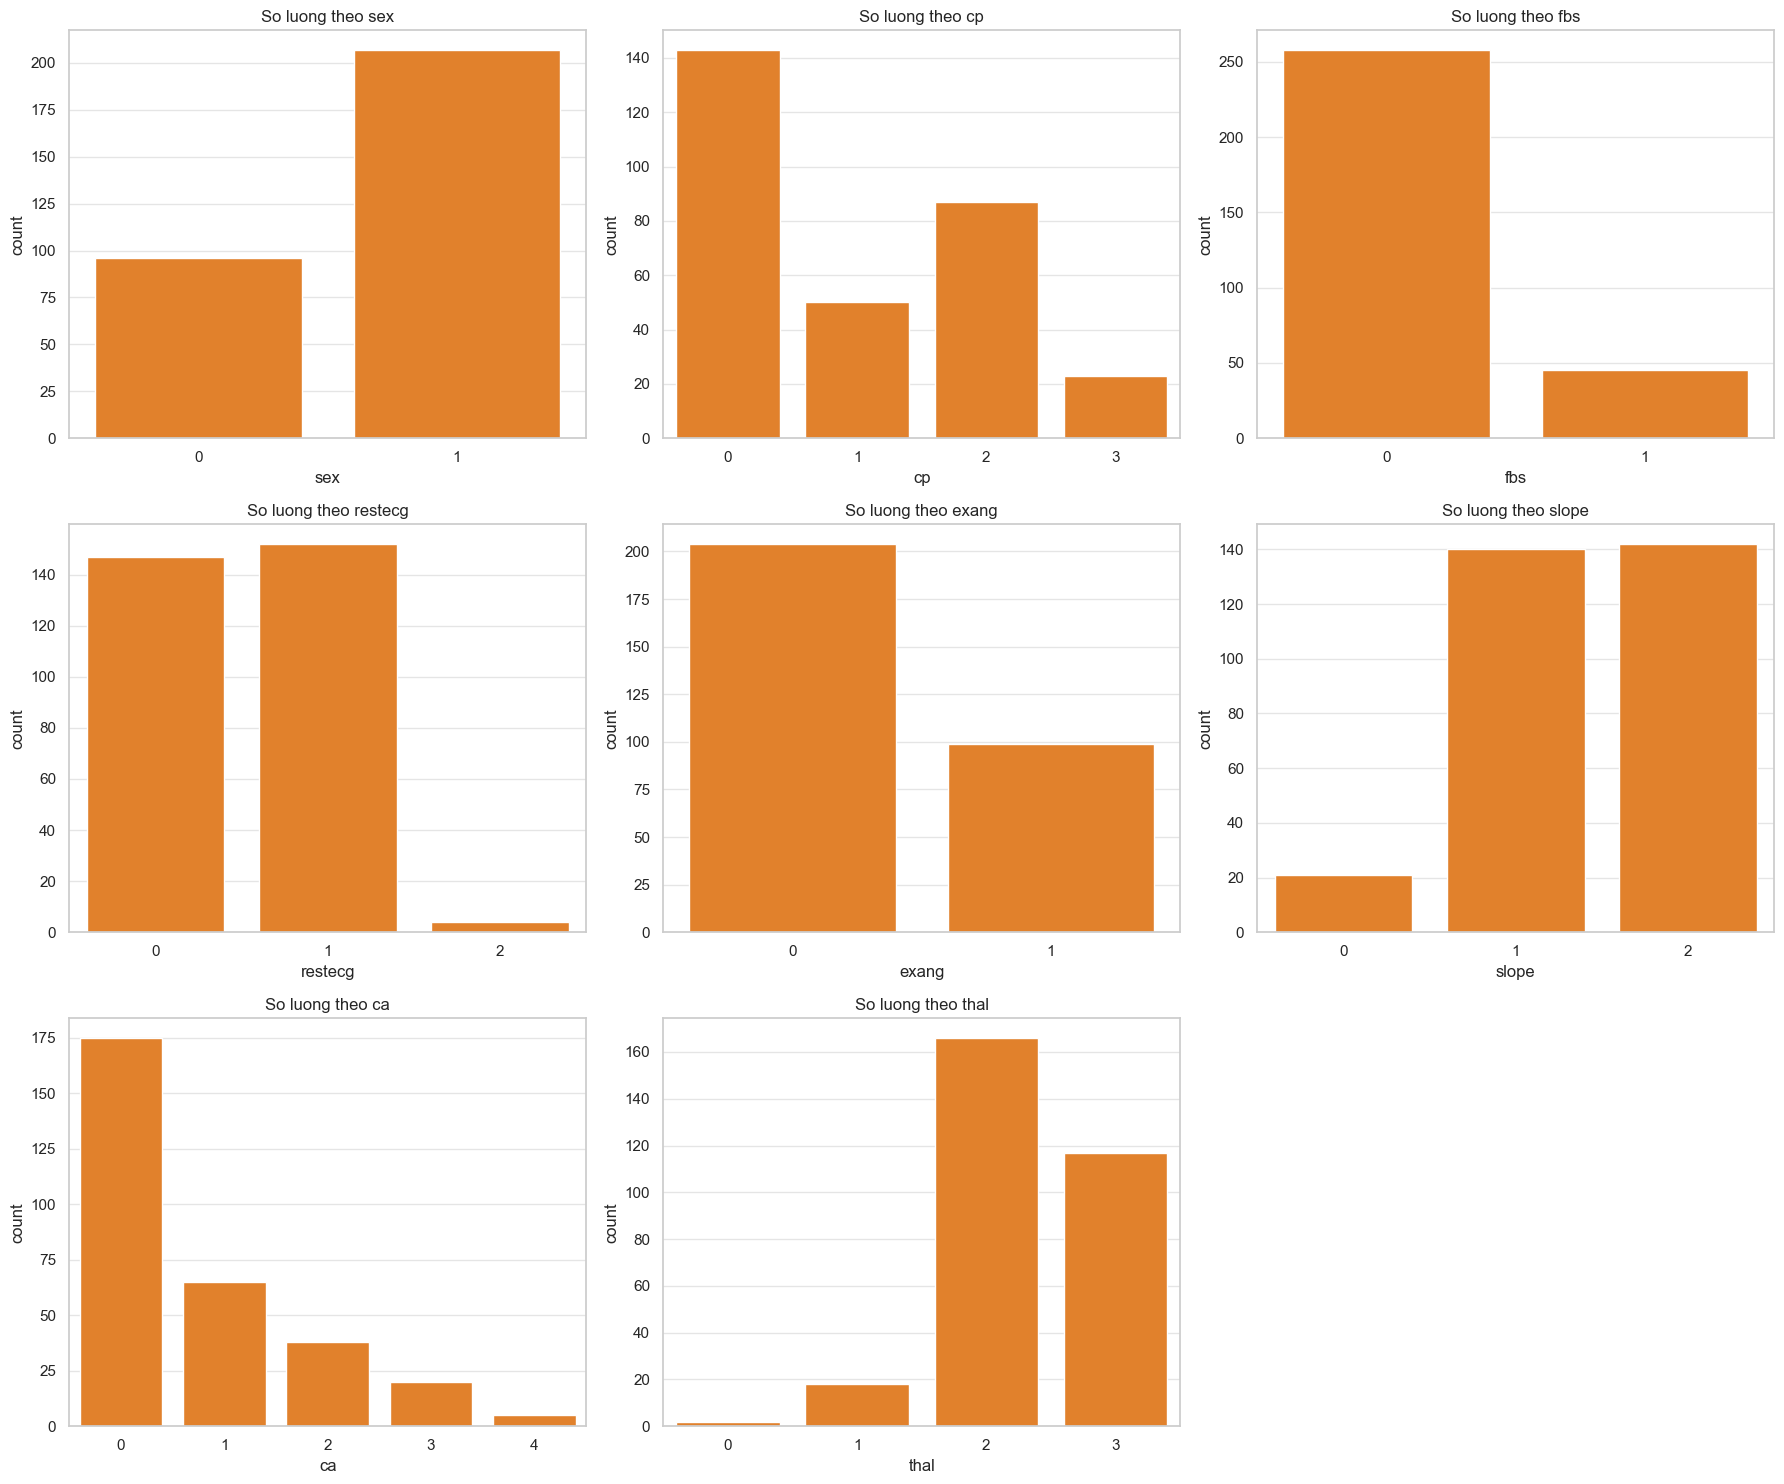

In [6]:
n_cols = 3
n_rows = math.ceil(len(categorical_no_target) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.ravel()
for ax, column in zip(axes, categorical_no_target):
    sns.countplot(data=data, x=column, ax=ax, color="#ff7f0e")
    ax.set_title(f"So luong theo {column}")
for ax in axes[len(categorical_no_target):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Box Plots to check distribution of continuous features by target class

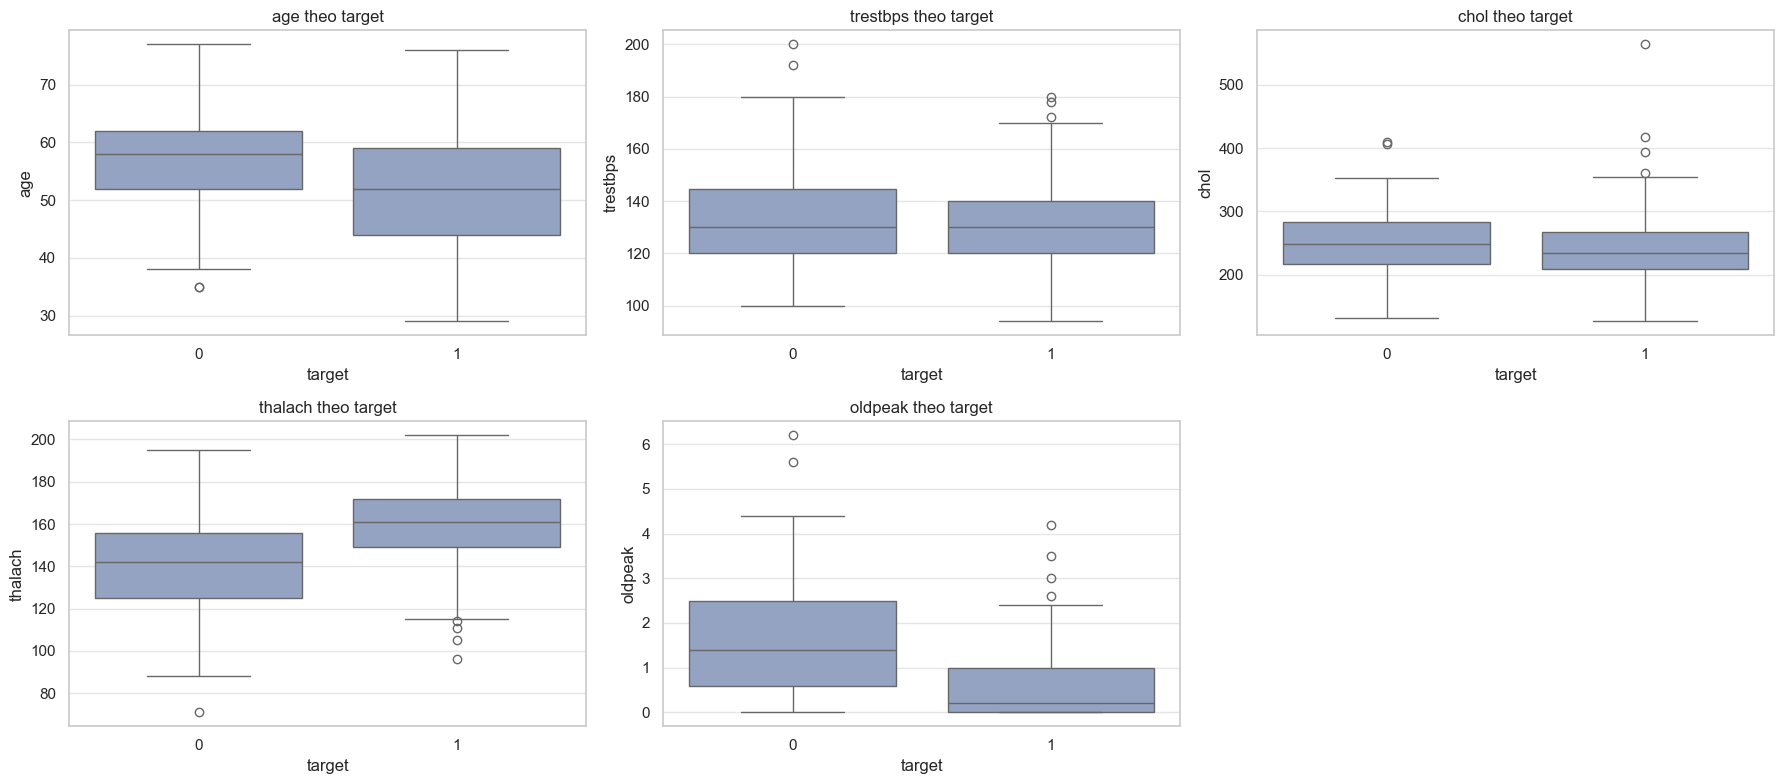

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()
for ax, column in zip(axes, CONTINUOUS_FEATURES):
    sns.boxplot(data=data, x="target", y=column, ax=ax, color="#8da0cb")
    ax.set_title(f"{column} theo target")
for ax in axes[len(CONTINUOUS_FEATURES):]:
    ax.axis("off")
plt.tight_layout()
plt.show()